In [1]:
# PyTorch core
import torch  # Main PyTorch library for tensors and operations

# NumPy and Pandas for data manipulation
import numpy as np  # For numerical operations
import pandas as pd  # For handling tabular data (DataFrames)

# Matplotlib for visualization
import matplotlib.pyplot as plt  # For plotting graphs

# Time tracking
import time  # For measuring training or execution time

# PyTorch neural network and optimization modules
import torch.nn as nn  # To define neural network layers and architectures
import torch.optim as optim  # For optimization algorithms like SGD, Adam, etc.

# PyTorch utilities for dataset handling
from torch.utils.data import DataLoader, TensorDataset  # For batching and shuffling data

# Progress bar for loops
from tqdm.notebook import tqdm, trange  # For displaying progress bars in notebooks

# Data preprocessing
from sklearn.preprocessing import StandardScaler  # For feature normalization (zero mean, unit variance)

# Load California housing dataset
from sklearn.datasets import fetch_california_housing  # Fetch the dataset used for regression

# Train/validation/test splitting
from sklearn.model_selection import train_test_split  # For splitting the dataset into train/val/test


# 🧠 Tropical Neural Network for California Housing Price Regression

## 📘 Project Overview

This notebook explores the application of **tropical algebra** within a custom neural network to predict **housing prices** using the **California Housing dataset**.

While traditional neural networks rely on standard linear algebra operations followed by common activation functions (like ReLU, tanh, or sigmoid), this project introduces a novel approach where:

- The **pre-activation transformation** (i.e., the operation before applying an activation function) is based on **tropical algebra**, specifically using the **max-plus semiring**.
- The **training process**, however, still leverages standard optimization techniques (e.g., **backpropagation**, **stochastic gradient descent**, **MSE loss**), allowing integration into PyTorch's automatic differentiation framework.

## 🌴 What Is Tropical Algebra?

Tropical algebra is a mathematical structure where:

- **Addition** becomes `max(a, b)`
- **Multiplication** becomes `a + b`

This algebraic framework has unique properties that make it useful in:
- Discrete optimization
- Scheduling problems
- Control theory
- Tropical geometry
- Linearity in tropical domain

In our context, we reinterpret dense layers using tropical linear operations to model the network's transformations.

## 🎯 Objective

The goal is to assess whether tropical transformations can serve as a useful **nonlinear mechanism** in regression models, specifically to:

- Replace the traditional affine transformation in neural layers with tropical algebra
- Retain gradient-based optimization to fit the model to real-world data
- Benchmark the performance against standard architectures (in future work)
- Validate properties of the tropical neural network using the tropical simplex (in future work)

## 🏗️ Implementation Plan

1. **Load and preprocess** the California Housing dataset.
2. **Define a custom neural layer** that implements tropical operations (e.g., tropical matrix-vector product).
3. **Stack tropical layers** into a feed-forward architecture.
4. **Train the model** using MSE loss and Adam optimizer.
5. **Evaluate performance** on validation and test sets.


## 1. Data Loading and Preprocessing

In [2]:
# --------------------------------------------------
# 1. Load Dataset (California Housing for Regression)
# --------------------------------------------------
data = fetch_california_housing()

# Description of the features:
# 1. longitude: A measure of how far west a house is; a higher value is farther west
# 2. latitude: A measure of how far north a house is; a higher value is farther north
# 3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
# 4. totalRooms: Total number of rooms within a block
# 5. totalBedrooms: Total number of bedrooms within a block
# 6. population: Total number of people residing within a block
# 7. households: Total number of households (groups of people residing in a housing unit) for a block
# 8. medianIncome: Median income for households within a block (measured in tens of thousands of US Dollars)
# 9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
# 10. oceanProximity: Location of the house with respect to the ocean/sea

# Prepare the features and target
X_all_features = data.data
y_ch = data.target.reshape(-1, 1)
feature_names_ch = data.feature_names

# Create a DataFrame to easily select features by name
df_ch = pd.DataFrame(X_all_features, columns=feature_names_ch)

# --------------------------------------------------
# 2. Split the data into train, validation, and test sets
# --------------------------------------------------
X_train_ch, X_temp_ch, y_train_ch, y_temp_ch = train_test_split(
    X_all_features, y_ch, test_size=0.3, random_state=42
)
X_val_ch, X_test_ch, y_val_ch, y_test_ch = train_test_split(
    X_temp_ch, y_temp_ch, test_size=0.5, random_state=42
)

# --------------------------------------------------
# 3. Scale the numerical features using StandardScaler
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ch)
X_val_scaled = scaler.transform(X_val_ch)
X_test_scaled = scaler.transform(X_test_ch)

# --------------------------------------------------
# 4. Convert data to PyTorch tensors
# --------------------------------------------------
X_train = torch.from_numpy(X_train_scaled).float()
X_val   = torch.from_numpy(X_val_scaled).float()
X_test  = torch.from_numpy(X_test_scaled).float()

y_train = torch.from_numpy(y_train_ch).float()
y_val   = torch.from_numpy(y_val_ch).float()
y_test  = torch.from_numpy(y_test_ch).float()

# --------------------------------------------------
# 5. Useful dimensions for the model
# --------------------------------------------------
num_input_features = X_train.shape[1]
output_size_regression = y_train.shape[1]

print(f"• Number of input features: {num_input_features}")
print(f"• Output size (regression): {output_size_regression}")

# --------------------------------------------------
# 6. Create TensorDataset and DataLoader
# --------------------------------------------------
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

batch_size = 32  # You can adjust this batch size if needed

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

• Number of input features: 8
• Output size (regression): 1


## 2. Tropical MLP Implementation

In [4]:
class TropLayer(nn.Module):
    """
    A custom linear layer using tropical (max-plus) algebra.
    
    In tropical algebra:
      - "addition" is replaced by max(a, b)
      - "multiplication" is replaced by a + b

    This layer computes the tropical matrix-vector product:
        (Wx)_i = max_j (W_ij + x_j), followed by:
        - bias max: max(trop_output, bias)
        - ReLU-like cutoff: max(trop_output, 0)
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # Initialize weights with negative values to enforce sparsity
        self.W = nn.Parameter(-0.5 * torch.abs(torch.randn(out_features, in_features)))
        
        # Very low bias values initially (inactive)
        self.b = nn.Parameter(torch.full((out_features,), -1e4))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Compute all W_ij + x_j (broadcasting over batch)
        z_all = self.W.unsqueeze(0) + x.unsqueeze(1)  # Shape: (batch, out_features, in_features)
        
        # Tropical matrix-vector product: max over input dimension
        z_trop, _ = torch.max(z_all, dim=2)  # Shape: (batch, out_features)

        # Add tropical bias: max(z, b)
        z_trop = torch.max(z_trop, self.b.unsqueeze(0))  # Shape: (batch, out_features)

        # Apply ReLU-like activation: max(z, 0)
        z_trop = torch.max(z_trop, torch.zeros_like(z_trop))

        return z_trop


class TropMLP(nn.Module):
    """
    A tropical MLP (multi-layer perceptron) that stacks multiple TropLayers.
    
    Parameters:
        - input_size: number of input features
        - output_size: number of outputs (1 for regression)
        - hidden_size: number of units in each hidden layer
        - num_layers: total number of tropical layers (≥1)
    """
    def __init__(self, input_size: int, output_size: int, hidden_size: int = 128, num_layers: int = 1):
        super().__init__()
                
        # First hidden layer: from input features to hidden representation
        self.first_hidden = TropLayer(input_size, hidden_size)

        # Hidden layers (optional)
        self.hidden_layers = nn.ModuleList([
            TropLayer(hidden_size, hidden_size) for _ in range(num_layers - 1)
        ])

        # Output layer
        self.outputlay = TropLayer(hidden_size, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.first_hidden(x)
            for layer in self.hidden_layers:
                x = layer(x)
            x = self.outputlay(x)
            return x

## 3. Definition of Training, Validation, and Testing Modules

### 3.1 Training

In [5]:
def train(model, iterator, optimizer, criterion):
    """
    Trains the model for one epoch using the provided data iterator.

    Args:
        model: the neural network model (e.g., TropMLP)
        iterator: DataLoader that yields batches of (x, y) for training
        optimizer: optimization algorithm (e.g., Adam)
        criterion: loss function (e.g., nn.MSELoss)

    Returns:
        train_loss: weighted average loss over all training examples
    """
    epoch_loss = 0.0
    total_examples = 0

    model.train()  # Set model to training mode

    for (x, y) in tqdm(iterator, desc="Training", leave=False):
        optimizer.zero_grad()         # Reset gradients
        predictions = model(x)        # Forward pass

        loss = criterion(predictions, y)  # Compute loss
        loss.backward()              # Backpropagation
        optimizer.step()             # Update parameters

        batch_size = x.size(0)
        total_examples += batch_size
        epoch_loss += loss.item() * batch_size  # Weighted loss sum

    train_loss = epoch_loss / total_examples
    return train_loss


### 3.2 Validation

In [6]:
def validate(model, iterator, mse_loss_fn):
    """
    Evaluates the model on a validation set and returns the average MSE.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the validation data
        mse_loss_fn: instance of torch.nn.MSELoss()

    Returns:
        avg_mse: mean squared error averaged over all validation examples
    """
    model.eval()  # Set model to evaluation mode
    total_mse = 0.0
    total_examples = 0

    with torch.no_grad():  # Disable gradient computation
        for x, y in tqdm(iterator, desc="Validating", leave=False):
            predictions = model(x)                  # Forward pass
            mse = mse_loss_fn(predictions, y)       # Compute MSE
            batch_size = x.size(0)
            total_mse += mse.item() * batch_size    # Accumulate weighted MSE
            total_examples += batch_size

    avg_mse = total_mse / total_examples
    return avg_mse

### 3.3 Test Evaluation

In [7]:
def evaluate_test(model, iterator, mse_loss_fn, mae_loss_fn):
    """
    Evaluates the model on a test DataLoader and returns MSE, MAE, and RMSE.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the test data
        mse_loss_fn: instance of torch.nn.MSELoss()
        mae_loss_fn: instance of torch.nn.L1Loss()

    Returns:
        eval_mse: average Mean Squared Error (MSE)
        eval_mae: average Mean Absolute Error (MAE)
        eval_rmse: Root Mean Squared Error (RMSE) computed from the MSE
    """
    model.eval()  # Set model to evaluation mode
    total_mse = 0.0
    total_mae = 0.0
    total_examples = 0

    with torch.no_grad():  # Disable gradient computation
        for x, y in tqdm(iterator, desc="Testing", leave=False):
            predictions = model(x)                    # Forward pass
            batch_size = x.size(0)

            mse = mse_loss_fn(predictions, y)         # Compute MSE
            mae = mae_loss_fn(predictions, y)         # Compute MAE

            total_mse += mse.item() * batch_size      # Accumulate weighted MSE
            total_mae += mae.item() * batch_size      # Accumulate weighted MAE
            total_examples += batch_size

    eval_mse = total_mse / total_examples
    eval_mae = total_mae / total_examples
    eval_rmse = np.sqrt(eval_mse)

    return eval_mse, eval_mae, eval_rmse

## 4. Setup and Configuration

In [8]:
def epoch_time(start_time, end_time):
    """
    Calculates elapsed time between start and end timestamps.

    Args:
        start_time: float, start time in seconds
        end_time: float, end time in seconds

    Returns:
        elapsed_mins: integer number of minutes
        elapsed_secs: remaining seconds (after minutes are accounted for)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time // 60)
    elapsed_secs = int(elapsed_time % 60)
    return elapsed_mins, elapsed_secs

In [8]:
# Instantiate the TropMLP model with specified parameters
model = TropMLP(
    input_size=num_input_features,    # Number of input features
    hidden_size=128,                  # Size of hidden layers
    output_size=output_size_regression,  # Output size (1 for regression)
    num_layers=3                     # Number of TropLayer hidden layers
)

# Define Mean Squared Error as loss function for regression
criterion = nn.MSELoss()

# Use Adam optimizer with learning rate 0.03
optimizer = optim.Adam(model.parameters(), lr=3e-2)

## 5. Training and Validation Loop

In [9]:
EPOCHS = 100
best_valid_loss = float('inf')
results_Regression = []

for epoch in trange(EPOCHS, desc="Epochs"):
    start_time = time.monotonic()

    # Train for one epoch
    train_loss = train(model, train_loader, optimizer, criterion)

    # Validate model on validation set (MSE only)
    valid_loss = validate(model, valid_loader, criterion)

    # Save model if validation loss improves
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tropical-regression-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Store losses for later analysis
    results_Regression.append({
        "Train Loss": train_loss,
        "Valid Loss": valid_loss,
    })

    # Print epoch statistics
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f}')
    print(f'\tValid Loss (MSE): {valid_loss:.3f}')

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/452 [00:00<?, ?it/s]

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 3s
	Train Loss: 2.626
	Valid Loss (MSE): 1.100


Training:   0%|          | 0/452 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 99 | Epoch Time: 0m 2s
	Train Loss: 1.444
	Valid Loss (MSE): 0.768


Training:   0%|          | 0/452 [00:00<?, ?it/s]

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 100 | Epoch Time: 0m 2s
	Train Loss: 1.433
	Valid Loss (MSE): 0.774


## 6. Results

### 6.1 Training and Validation Loss Curves

In [10]:
def plot_results(results):
    """
    Plots training and validation loss over epochs.

    Args:
        results: pandas DataFrame with columns 'Train Loss' and 'Valid Loss', indexed by epoch
    """

    # Plot Training Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Train Loss'], label='Train Loss', marker='o')
    plt.title('Training Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Plot Validation Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Valid Loss'], label='Valid Loss', marker='s', color='orange')
    plt.title('Validation Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
# Convert list of dicts to DataFrame
results_Tropical = pd.DataFrame(results_Regression)

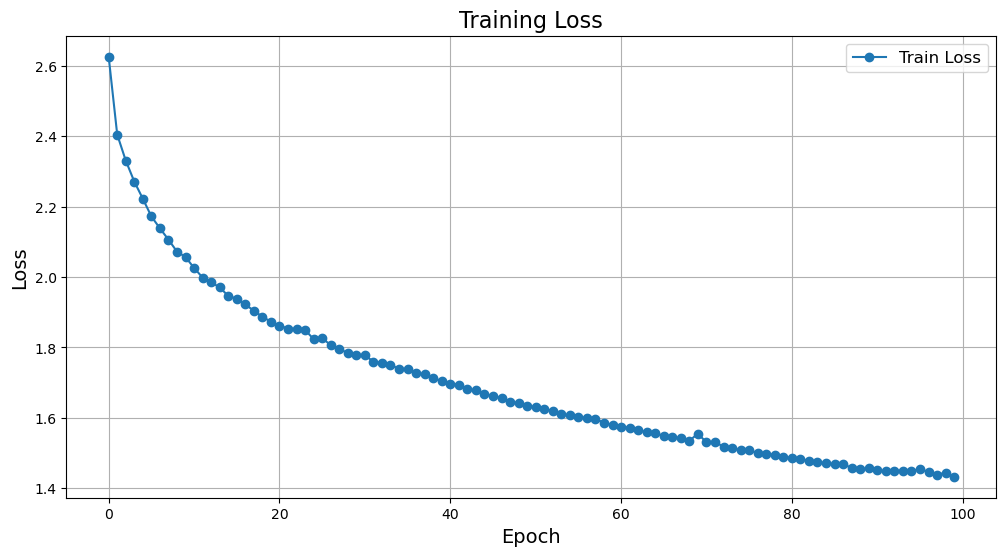

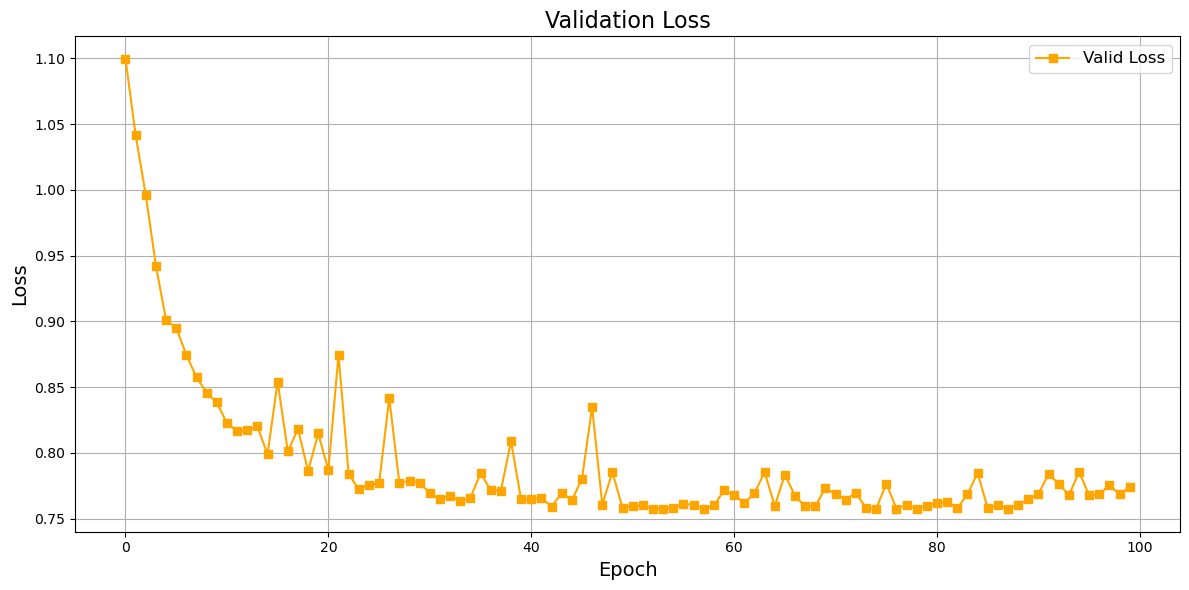

In [12]:
plot_results(results_Tropical)

### Test Results

In [13]:
# Load the best saved model weights
model.load_state_dict(torch.load('tropical-regression-model.pt'))

# Evaluate the model on the test set
test_mse, test_mae, test_rmse = evaluate_test(model, test_loader, nn.MSELoss(), nn.L1Loss())

print("\n--- Test Results ---")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

Testing:   0%|          | 0/97 [00:00<?, ?it/s]


--- Test Results ---
Test MSE  : 1.7369
Test MAE  : 0.6377
Test RMSE : 1.3179
